# Test cellcharter on xenium skin psoriasis data

## Load libraries

In [1]:
import anndata as ad
import squidpy as sq
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
import cellcharter as cc

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import json
from scipy import sparse
import os

In [4]:
import scvi
from lightning.pytorch import seed_everything

seed_everything(12345)
scvi.settings.seed = 12345

Seed set to 12345
Seed set to 12345


In [5]:
initDir = '/nfs/team361/ms83/data/skin/xenium_cellcharter/compatible_anndata/psoriasis/'
outDir = '/nfs/team361/ms83/data/skin/xenium_cellcharter/'

## Load adata with scVI embeddings (cell charter uses them)

File I am using: "/nfs/team361/ms83/data/skin/xenium_scviva/adata_psoriasis_preprocessed_scvi_emb.h5ad" but in its disassembled version.

In [6]:
def load_adata(input_directory: str) -> ad.AnnData:
    obs = pd.read_parquet(os.path.join(input_directory, "obs.parquet"))
    var = pd.read_parquet(os.path.join(input_directory, "var.parquet"))

    with open(os.path.join(input_directory, "uns.json"), "r") as file:
        uns = json.load(file)

    obsm_spatial = np.load(os.path.join(input_directory, "obsm_spatial.npy"))
    obsm_scVI = np.load(os.path.join(input_directory, "obsm_scVI.npy"))
    obsm_scANVI = np.load(os.path.join(input_directory, "obsm_scANVI.npy"))
    
    layers_counts = sparse.load_npz(os.path.join(input_directory, "layers_counts.npz"))

    x = sparse.load_npz(os.path.join(input_directory, "x.npz"))

    var_names = np.loadtxt(os.path.join(input_directory, "var_names.csv"), delimiter=",", dtype=str).tolist()
    obs_names = np.loadtxt(os.path.join(input_directory, "obs_names.csv"), delimiter=",", dtype=str).tolist()

    adata = ad.AnnData(X=x, obs=obs, var=var, uns=uns)
    adata.obsm["spatial"] = obsm_spatial
    adata.obsm["X_scVI"] = obsm_scVI
    adata.obsm["X_scANVI"] = obsm_scANVI
    adata.layers["counts"] = layers_counts
    adata.var_names = var_names
    adata.obs_names = obs_names

    return adata

In [7]:
adata = load_adata('/nfs/team361/ms83/data/skin/xenium_cellcharter/compatible_anndata/psoriasis/')

In [8]:
adata

AnnData object with n_obs × n_vars = 22700 × 4772
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'xenium_id', 'xenium_id_recoded', 'Site_status', 'GSTT patient ID', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', "Library type (CITE or 5'GEX/TCR)", 'Segmentation Y/N?', 'Sample ID', 'Xenium slide number', 'Xenium region number2', 'baseline_postrx', 'info_id', 'Annotation', 'NICHE_NAMES', 'batch', 'DonorID', 'leiden_res1', 'leiden_res2', 'new_annotation', 'new_annotation2', 'new_annotation3', 'annotation_new4', 'new_annotation4',

In [9]:
sq.gr.spatial_neighbors(adata, library_key='info_id', coord_type='generic', delaunay=True, spatial_key='spatial', percentile=99)

In [10]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cellcharter', sample_key='info_id')

100%|██████████| 4/4 [00:00<00:00, 45.11it/s]


In [11]:
autok = cc.tl.ClusterAutoK(
    n_clusters=(2,10), 
    max_runs=10,
    convergence_tol=0.001
)

In [12]:
autok.fit(adata, use_rep='X_cellcharter')

Iteration 1/10


  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:01<00:19,  1.98s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:03<00:15,  1.69s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:04<00:09,  1.25s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

Iteration 2/10


  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:01<00:14,  1.42s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:02<00:13,  1.48s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:04<00:11,  1.46s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

Iteration 3/10


...

  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:01<00:12,  1.29s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:03<00:14,  1.67s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:03<00:09,  1.21s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

Iteration 9/10


  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:01<00:13,  1.31s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:02<00:12,  1.40s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:04<00:11,  1.41s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

Iteration 10/10


  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:01<00:12,  1.29s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:02<00:12,  1.39s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:04<00:11,  1.43s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

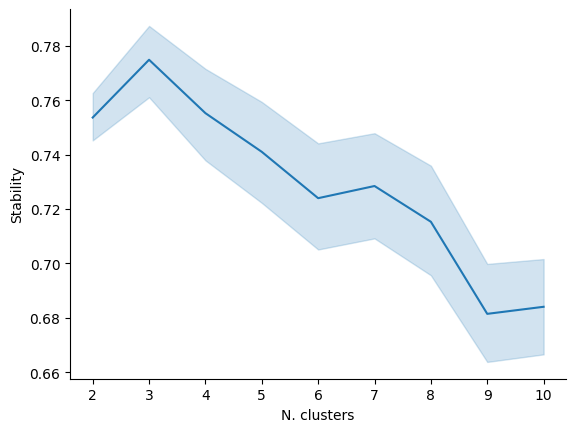

In [13]:
cc.pl.autok_stability(autok)

In [14]:
adata.obs['cluster_cellcharter'] = autok.predict(adata, use_rep='X_cellcharter')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [15]:
adata

AnnData object with n_obs × n_vars = 22700 × 4772
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'xenium_id', 'xenium_id_recoded', 'Site_status', 'GSTT patient ID', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', "Library type (CITE or 5'GEX/TCR)", 'Segmentation Y/N?', 'Sample ID', 'Xenium slide number', 'Xenium region number2', 'baseline_postrx', 'info_id', 'Annotation', 'NICHE_NAMES', 'batch', 'DonorID', 'leiden_res1', 'leiden_res2', 'new_annotation', 'new_annotation2', 'new_annotation3', 'annotation_new4', 'new_annotation4',

In [16]:
adata.write_h5ad(outDir + 'adata_psoriasis_preprocessed_cellcharter_emb.h5ad')

TypeError: Can't implicitly convert non-string objects to strings

In [ ]:
adata.obs.info_id.value_counts()

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


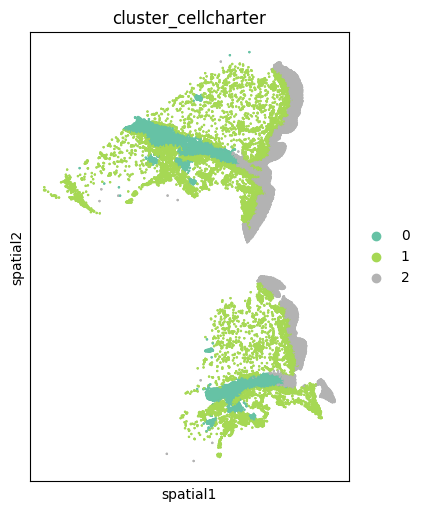

In [31]:
sq.pl.spatial_scatter(
    adata, 
    color=['cluster_cellcharter'], 
    library_key='info_id',  
    size=2, 
    img=None,
    spatial_key='spatial',
    shape=None,
    palette='Set2',
    figsize=(5,5),
    ncols=1,
    library_id=['BK30_Day 14'],
)

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


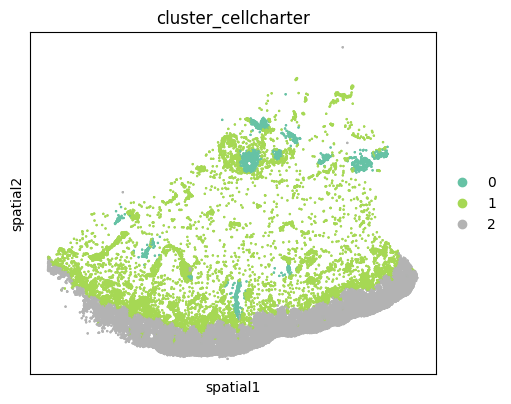

In [32]:
sq.pl.spatial_scatter(
    adata, 
    color=['cluster_cellcharter'], 
    library_key='info_id',  
    size=2, 
    img=None,
    spatial_key='spatial',
    shape=None,
    palette='Set2',
    figsize=(5,5),
    ncols=1,
    library_id=['BK23_Lesional Baseline'],
)

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


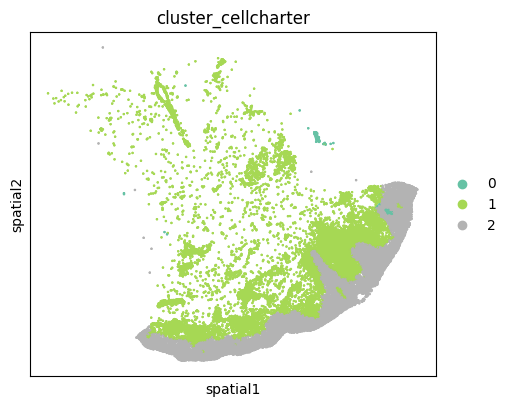

In [33]:
sq.pl.spatial_scatter(
    adata, 
    color=['cluster_cellcharter'], 
    library_key='info_id',  
    size=2, 
    img=None,
    spatial_key='spatial',
    shape=None,
    palette='Set2',
    figsize=(5,5),
    ncols=1,
    library_id=['BK22_Lesional Baseline'],
)

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


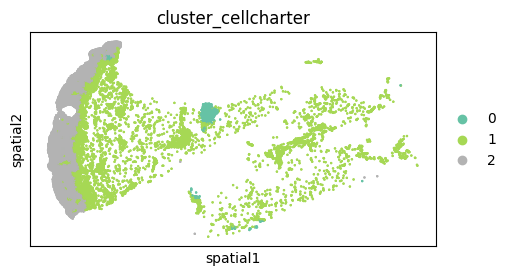

In [35]:
sq.pl.spatial_scatter(
    adata, 
    color=['cluster_cellcharter'], 
    library_key='info_id',  
    size=2, 
    img=None,
    spatial_key='spatial',
    shape=None,
    palette='Set2',
    figsize=(5,5),
    ncols=1,
    library_id=['BK23_Non-lesional Baseline'],
)